In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import utils
import paths as p

In [2]:
qc_dir = p.DATA_DIR / 'qc_metrics'
if not qc_dir.exists():
    os.makedirs(qc_dir)

In [3]:
units_all = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_all.csv'), index_col=0)

In [4]:
sessions_all = pd.read_csv(os.path.join(p.LOGS_DIR, 'sessions_all.csv'), index_col=0)
sessions_all = sessions_all.rename(columns={'id': 'session_id'})

if 'datetime' in sessions_all.columns:
    sessions_all['date'] = pd.to_datetime(sessions_all['datetime']).dt.normalize()

def has_str_and_v1(regions):
    return ('str' in regions.values) and ('v1' in regions.values)

sessions_all['simultaneous'] = sessions_all.groupby(['mouse', 'date'])['region'].transform(has_str_and_v1)

In [5]:
units_all_merged = units_all.merge(
    sessions_all[['session_id', 'mouse', 'insertion_number', 'datetime', 'paramset_idx', 'simultaneous']],
    on='session_id',
    how='left'
)

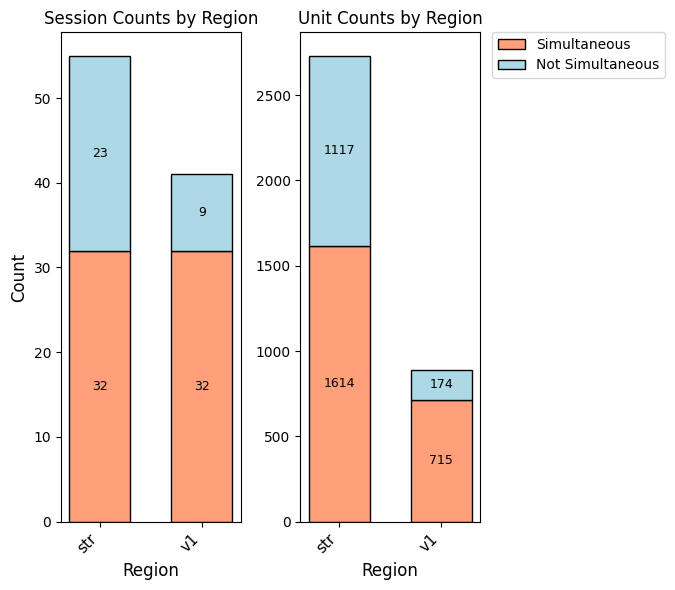

In [6]:
# Sessions subplot
region_simul_counts_sessions = sessions_all.groupby(['region', 'simultaneous']).size().reset_index(name='count')
pivot_sessions = region_simul_counts_sessions.pivot(index='region', columns='simultaneous', values='count').fillna(0)
pivot_sessions = pivot_sessions.reindex(columns=[True, False], fill_value=0)

# Units subplot
region_simul_counts_units = units_all_merged.groupby(['region', 'simultaneous']).size().reset_index(name='count')
pivot_units = region_simul_counts_units.pivot(index='region', columns='simultaneous', values='count').fillna(0)
pivot_units = pivot_units.reindex(columns=[True, False], fill_value=0)


x = np.arange(len(pivot_sessions.index))
bar_width = 0.6

fig, axs = plt.subplots(1, 2, figsize=(5, 6))

# Sessions plot
bars_sess_simul = axs[0].bar(x, pivot_sessions[True], width=bar_width, label='Simultaneous', color='lightsalmon', edgecolor='black')
bars_sess_nonsimul = axs[0].bar(x, pivot_sessions[False], width=bar_width, bottom=pivot_sessions[True], label='Not Simultaneous', color='lightblue', edgecolor='black')
axs[0].set_xticks(x)
axs[0].set_xticklabels(pivot_sessions.index, rotation=45, ha='right', fontsize=11)
axs[0].set_title('Session Counts by Region')
axs[0].set_ylabel('Count', fontsize=12)
axs[0].set_xlabel('Region', fontsize=12)
# Value labels
for bar in bars_sess_simul + bars_sess_nonsimul:
    height = bar.get_height()
    if height > 0:
        axs[0].text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{int(height)}',
                    ha='center', va='center', fontsize=9, color='black')

# Units plot
bars_units_simul = axs[1].bar(x, pivot_units[True], width=bar_width, label='Simultaneous', color='lightsalmon', edgecolor='black')
bars_units_nonsimul = axs[1].bar(x, pivot_units[False], width=bar_width, bottom=pivot_units[True], label='Not Simultaneous', color='lightblue', edgecolor='black')
axs[1].set_xticks(x)
axs[1].set_xticklabels(pivot_units.index, rotation=45, ha='right', fontsize=11)
axs[1].set_title('Unit Counts by Region')
axs[1].set_xlabel('Region', fontsize=12)
# Value labels
for bar in bars_units_simul + bars_units_nonsimul:
    height = bar.get_height()
    if height > 0:
        axs[1].text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{int(height)}',
                    ha='center', va='center', fontsize=9, color='black')

# Add one legend to the right of the plots
handles, labels = axs[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.9))

plt.tight_layout()
plt.savefig(os.path.join(p.FIGURES_DIR, 'region_simultaneous_counts.png'), dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print("Summary Statistics:")
print("total sessions:", len(sessions_all))
print("num str sessions:", pivot_sessions.loc['str'].sum())
print("num v1 sessions:", pivot_sessions.loc['v1'].sum())
print("simultaneous sessions:", pivot_sessions.loc['str', True])
print()
print("total units:", len(units_all_merged))
print("num str units:", pivot_units.loc['str'].sum())
print("num v1 units:", pivot_units.loc['v1'].sum())

Summary Statistics:
total sessions: 96
num str sessions: 55
num v1 sessions: 41
simultaneous sessions: 32

total units: 3620
num str units: 2731
num v1 units: 889


# QC

In [8]:
units_vetted = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_vetted.csv'), index_col=0)
units_all = pd.read_csv(os.path.join(p.LOGS_DIR, 'units_all.csv'), index_col=0)

In [9]:
units_merged = units_all.merge(
    sessions_all[['session_id', 'mouse', 'insertion_number', 'datetime', 'paramset_idx', 'simultaneous']],
    on='session_id',
    how='left'
)

In [10]:
# qc_df = pd.read_csv(os.path.join(p.LOGS_DIR, 'RZ_quality_metrics.csv'), index_col=0)
qc_df = pd.read_csv(os.path.join(p.LOGS_DIR, 'RZ_quality_metrics.csv'))
qc_df = qc_df.rename(columns={'subject': 'mouse', 'unit':'id', 'session_datetime':'datetime'})

In [11]:
# Merge qc_df info into units_all_merged based on the specified columns
cols = ['mouse', 'datetime', 'insertion_number', 'paramset_idx', 'id']

units_with_qc = units_merged.merge(
    qc_df,
    on=cols,
    how='left',
    suffixes=('', '_qc')
)

In [12]:
df = units_with_qc.copy()

# ---- 2) Define QC thresholds ----
qc_thresholds = {
    "firing_rate": (">", 0.1),            # > 0.1 Hz
    "isi_violation": ("<", 1),            # < 1
    "amplitude_cutoff": ("<", 0.01),         # < 0.01
    "presence_ratio": (">", 0.80),           # > 0.8
    "isolation_distance": (">", 20.0),       # > 20
    "snr": (">", 5.0),                       # > 5
    "contamination_rate": ("<", 0.20),       # < 0.2
}
qc_thresholds_secondary = {
    "l_ratio":          ("<", 0.20),   # lower = cleaner; <0.1 is stricter
    "d_prime":          (">", 2),    # >3.0 is stricter; higher = better separation
    "nn_hit_rate":      (">", 0.8),   # purity, closer to 1 is better
    "nn_miss_rate":     ("<", 0.2),   # completeness, closer to 0 is better
    "silhouette_score": (">", 0.40),   # >0.5 stricter; -1..1 scale
    "max_drift":        ("<", 30.0),   # µm; <25 strict, 30 realistic for 1–2 h sessions
    "cumulative_drift": ("<", 10.0),  # µm; depends on duration; <80 stricter
}

In [13]:
def hist_plot(series, title, bins=50, filename=None, xlim=None, qc_threshold=None):
    plt.figure(figsize=(8, 5), dpi=140)
    sns.histplot(series.dropna(), bins=bins, color='cornflowerblue', edgecolor='black')
    plt.title(title)
    plt.ylabel("Count")
    if qc_threshold is not None:
        plt.axvline(qc_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {qc_threshold}')
    if xlim is not None:
        plt.xlim(*xlim)
    plt.tight_layout()
    if filename:
        plt.savefig(qc_dir / filename, bbox_inches="tight")
    plt.show()

In [14]:
def hist_plot(series, title, bins=50, filename=None, xlim=None, qc_threshold=None):
    plt.figure(figsize=(8, 5), dpi=140)
    sns.histplot(series.dropna(), bins=bins, color='cornflowerblue', edgecolor='black')
    plt.title(title)
    plt.ylabel("Count")
    # Add shading for "kept" region
    if qc_threshold is not None:
        op = qc_threshold[0]
        threshold = qc_threshold[1]
        if op == ">":
            plt.axvspan(threshold, plt.xlim()[1], color='skyblue', alpha=0.18, label='Kept region')
        elif op == "<":
            plt.axvspan(plt.xlim()[0], threshold, color='skyblue', alpha=0.18, label='Kept region')
        plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold}')
        plt.legend()
    if xlim is not None:
        plt.xlim(*xlim)
    plt.tight_layout()
    if filename:
        plt.savefig(qc_dir / filename, bbox_inches="tight")
    plt.show()

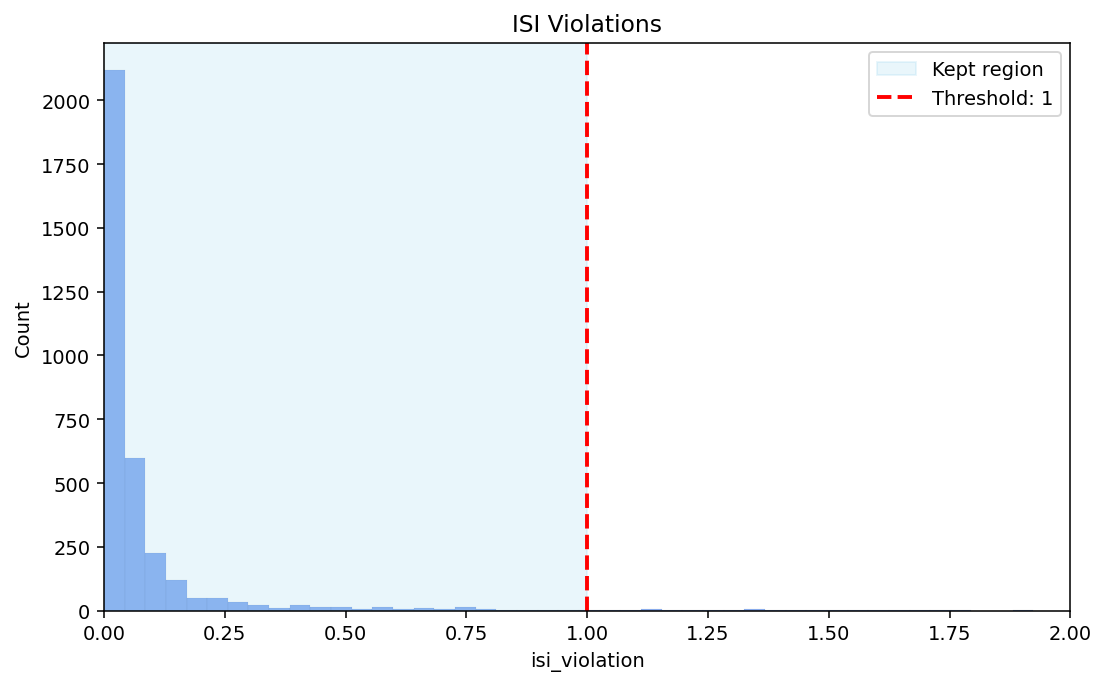

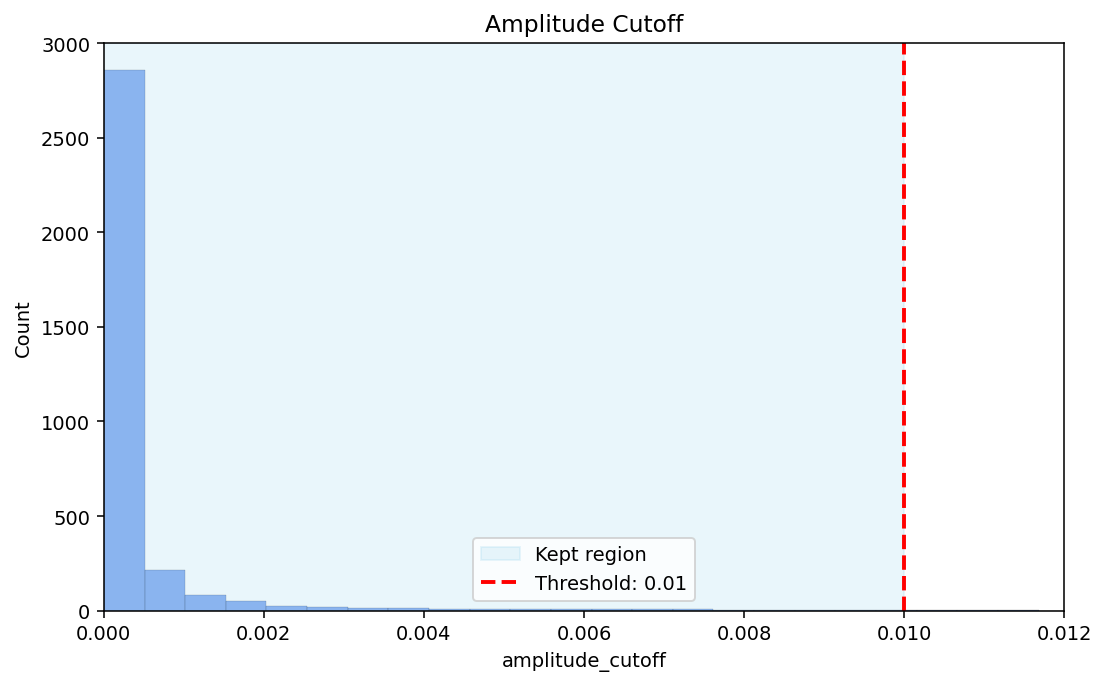

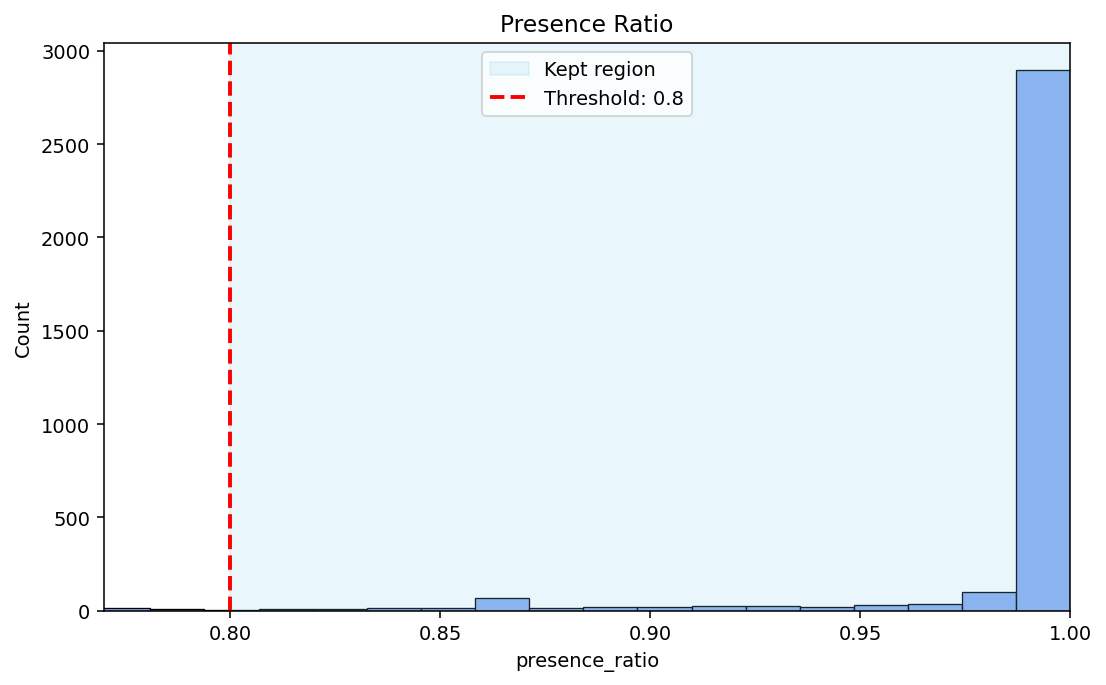

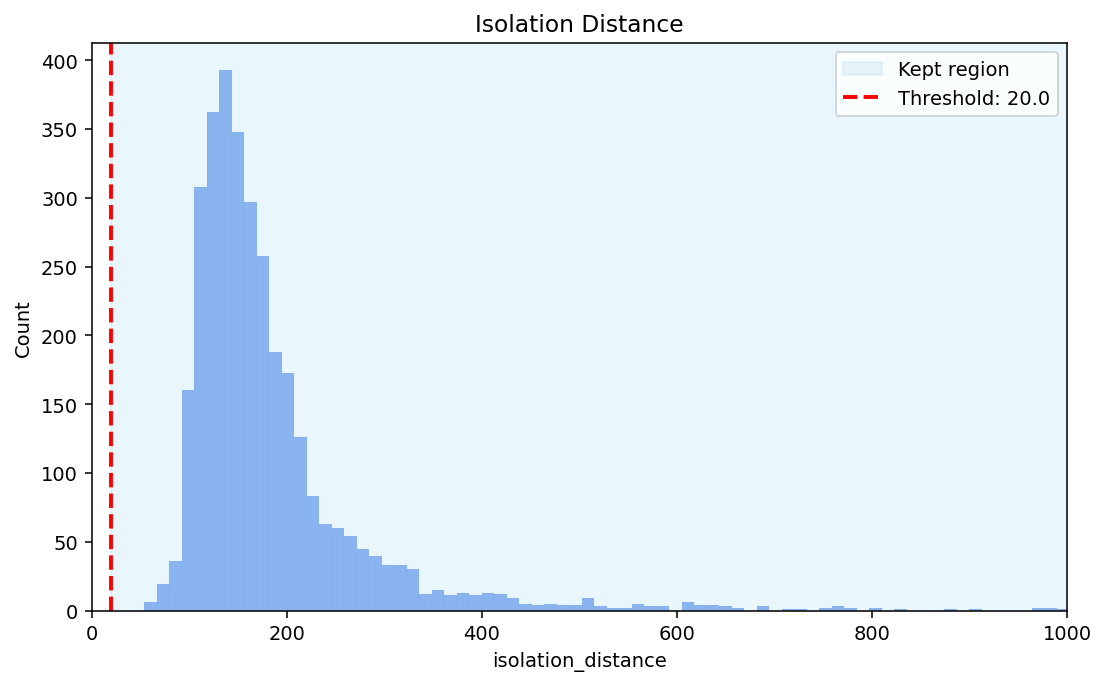

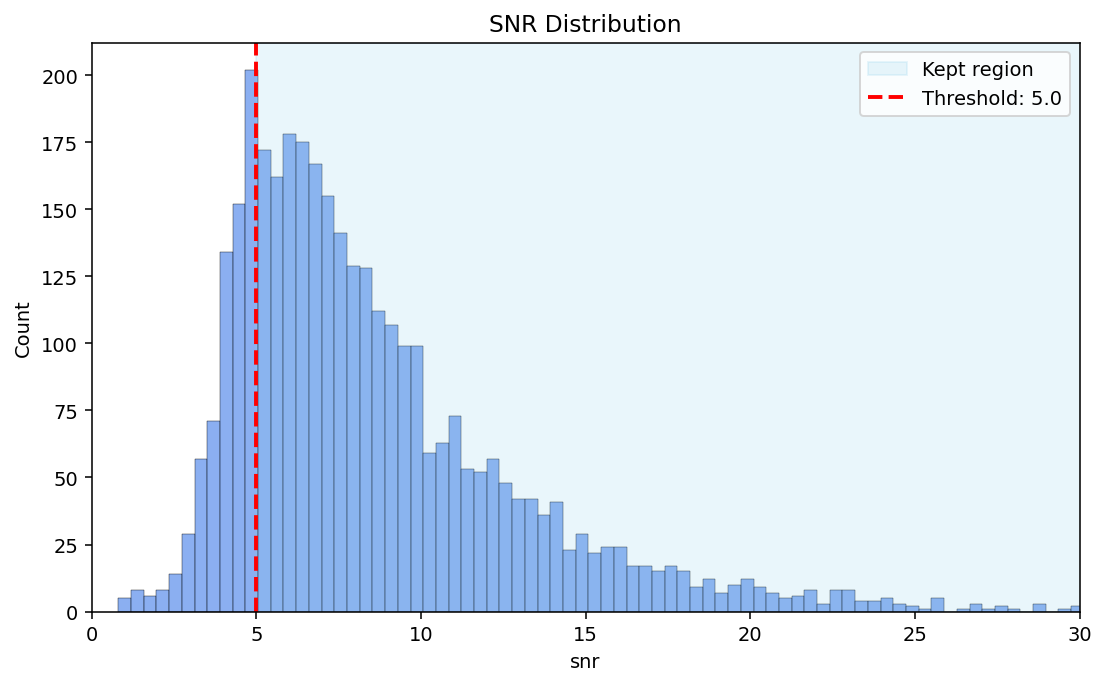

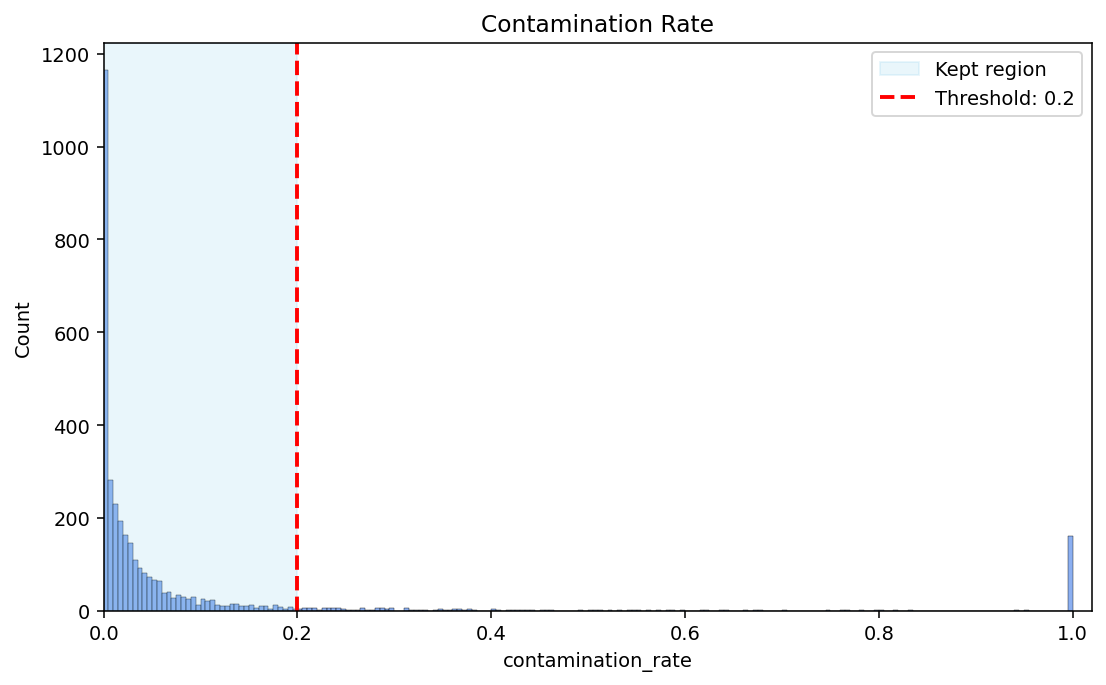

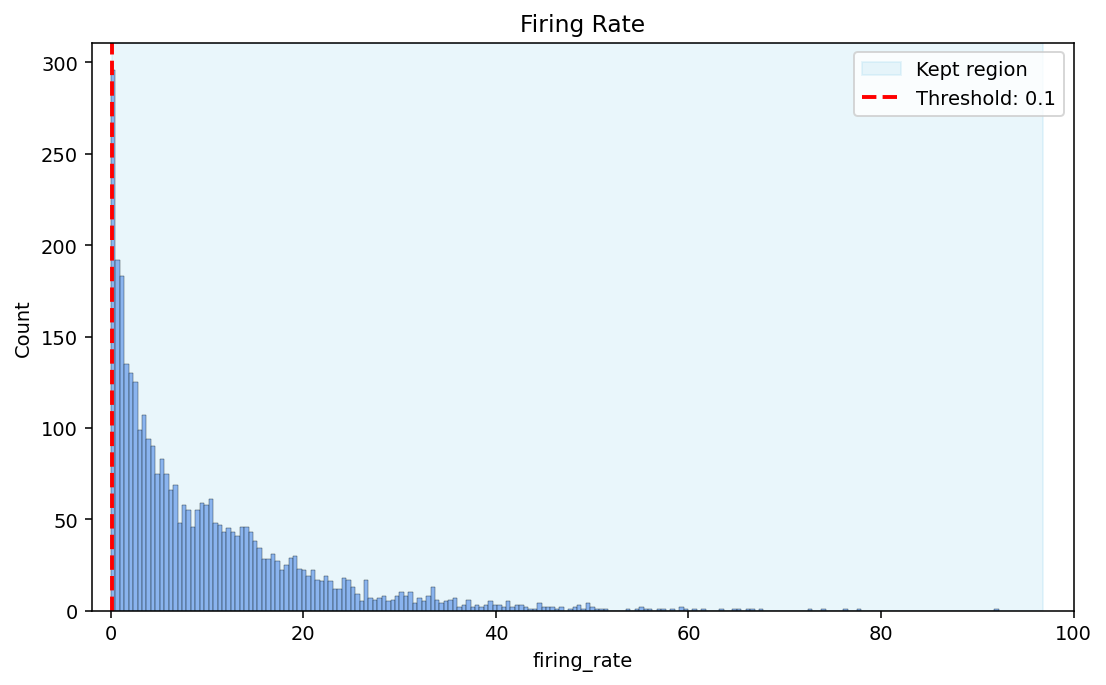

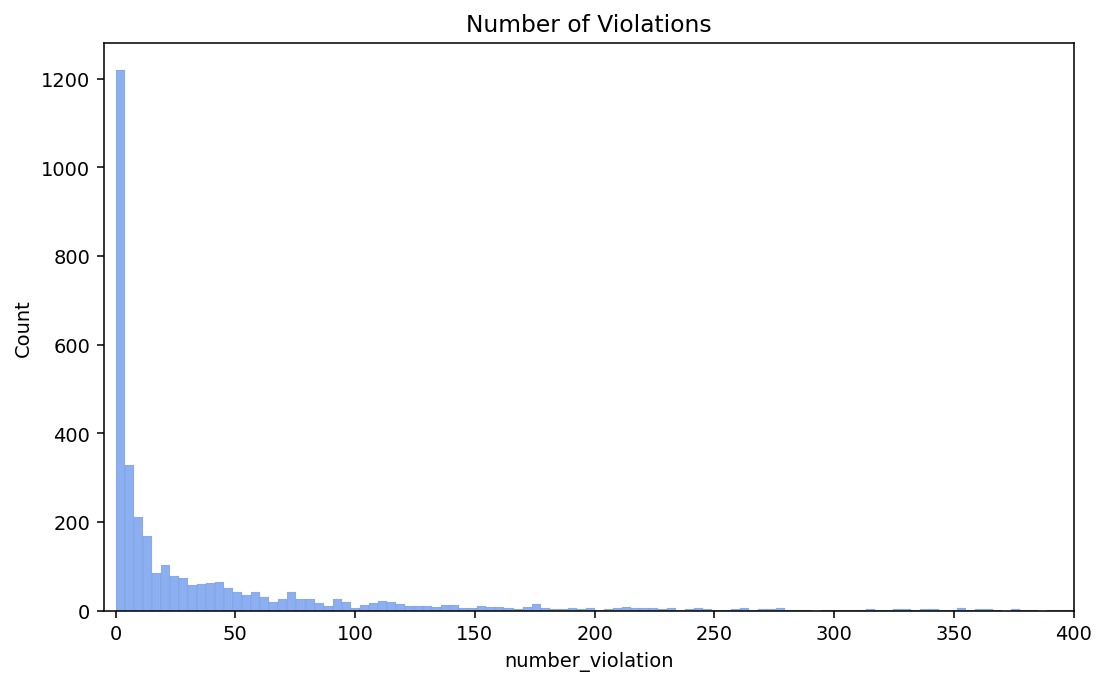

In [15]:
# For isi_violation
to_plot = "isi_violation"
hist_plot(df[to_plot], "ISI Violations" , bins=2000, filename=f"hist_{to_plot}.png", xlim=(0, 2), qc_threshold=qc_thresholds[to_plot])

# For amplitude_cutoff
to_plot = "amplitude_cutoff"
hist_plot(df[to_plot], "Amplitude Cutoff", bins=500, filename=f"hist_{to_plot}.png", xlim=(0, 0.012), qc_threshold=qc_thresholds[to_plot])

# For presence_ratio
to_plot = "presence_ratio"
hist_plot(df[to_plot], "Presence Ratio", bins=60, filename=f"hist_{to_plot}.png", xlim=(0.77, 1.0), qc_threshold=qc_thresholds[to_plot])

# For isolation_distance
to_plot = "isolation_distance"
hist_plot(df[to_plot], "Isolation Distance", bins=5000, filename=f"hist_{to_plot}.png", xlim=(0, 1000), qc_threshold=qc_thresholds[to_plot])

# For snr
to_plot = "snr"
hist_plot(df[to_plot], "SNR Distribution", bins=200, filename=f"hist_{to_plot}.png", xlim=(0, 30), qc_threshold=qc_thresholds[to_plot])

# For contamination_rate
to_plot = "contamination_rate"
hist_plot(df[to_plot], "Contamination Rate", bins=200, filename=f"hist_{to_plot}.png", xlim=(0, 1.02), qc_threshold=qc_thresholds[to_plot])

to_plot = "firing_rate"
hist_plot(df[to_plot], "Firing Rate", bins=200, filename=f"hist_{to_plot}.png", xlim=(-2, 100), qc_threshold=qc_thresholds[to_plot])

to_plot = "number_violation"
hist_plot(df[to_plot], "Number of Violations", bins=2000, filename=f"hist_{to_plot}.png", xlim=(-5, 400))

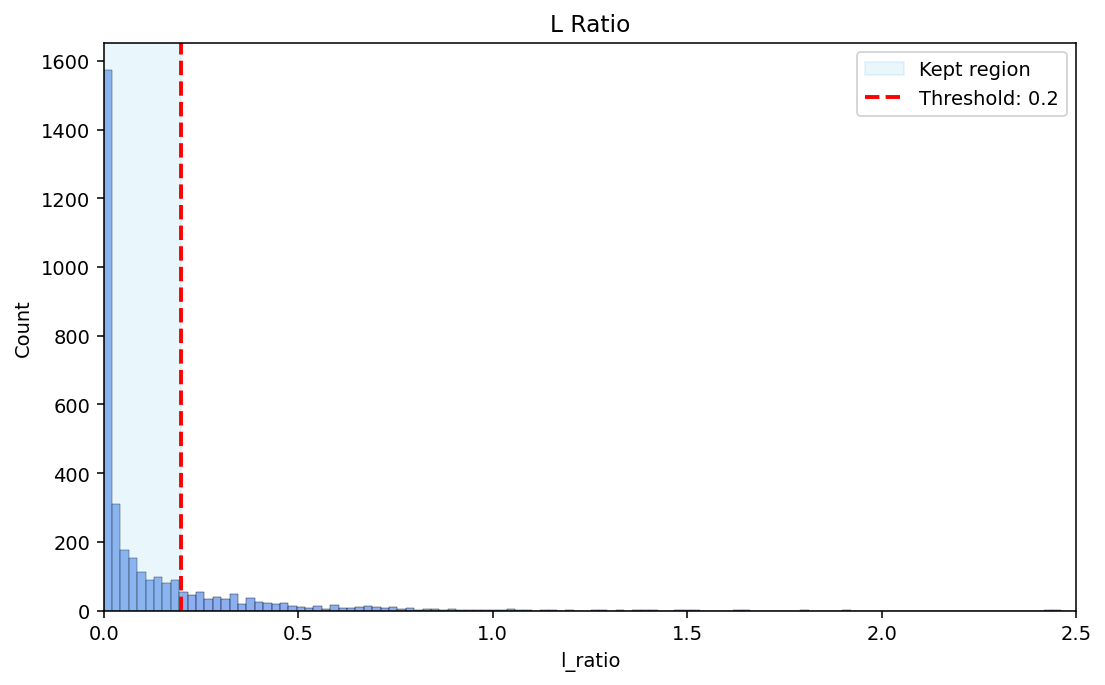

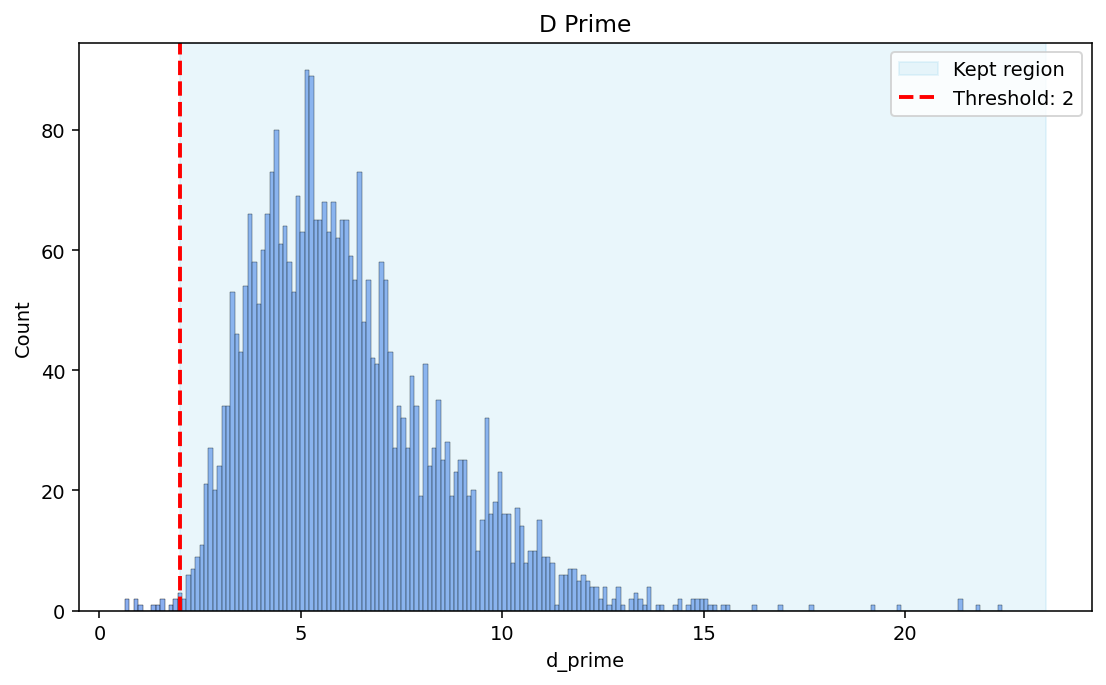

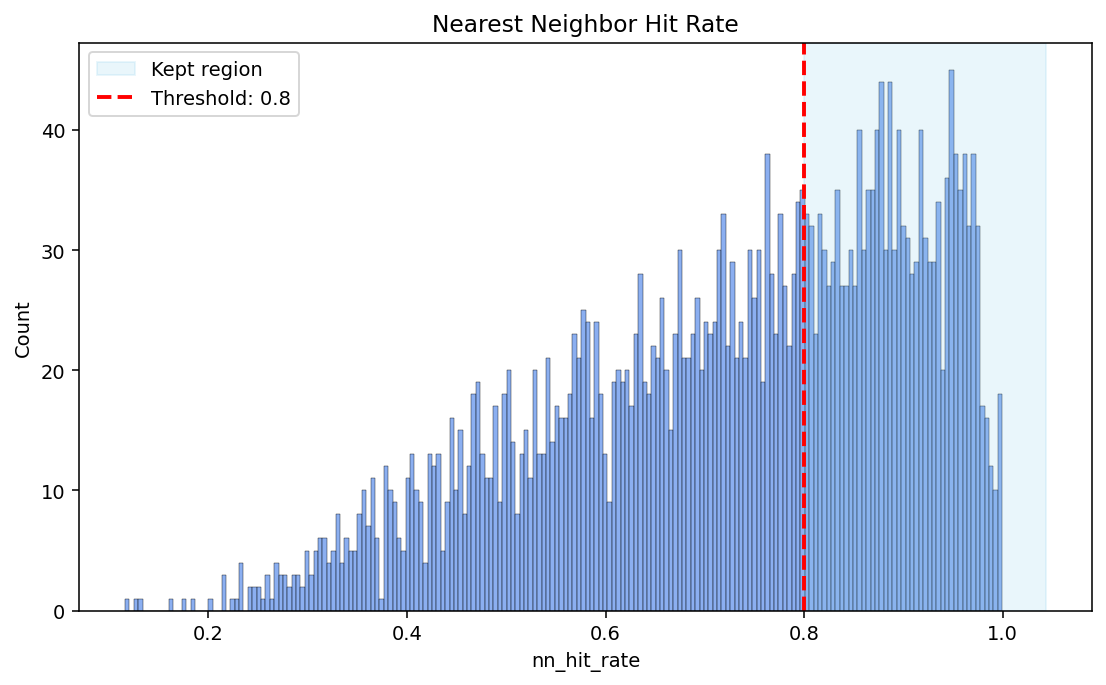

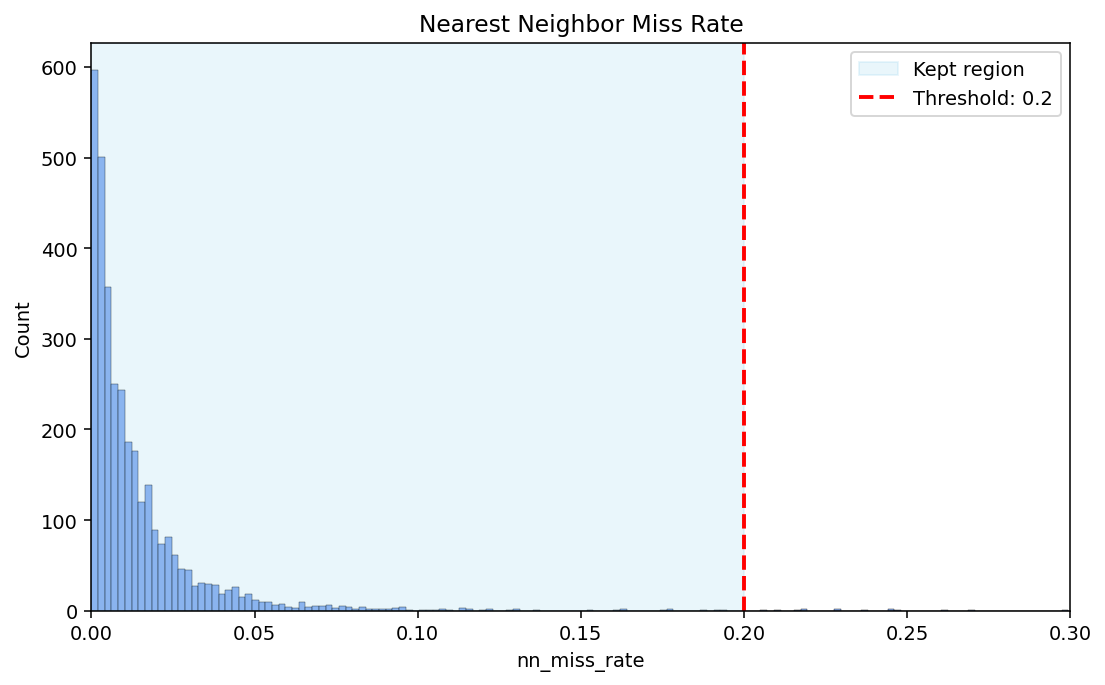

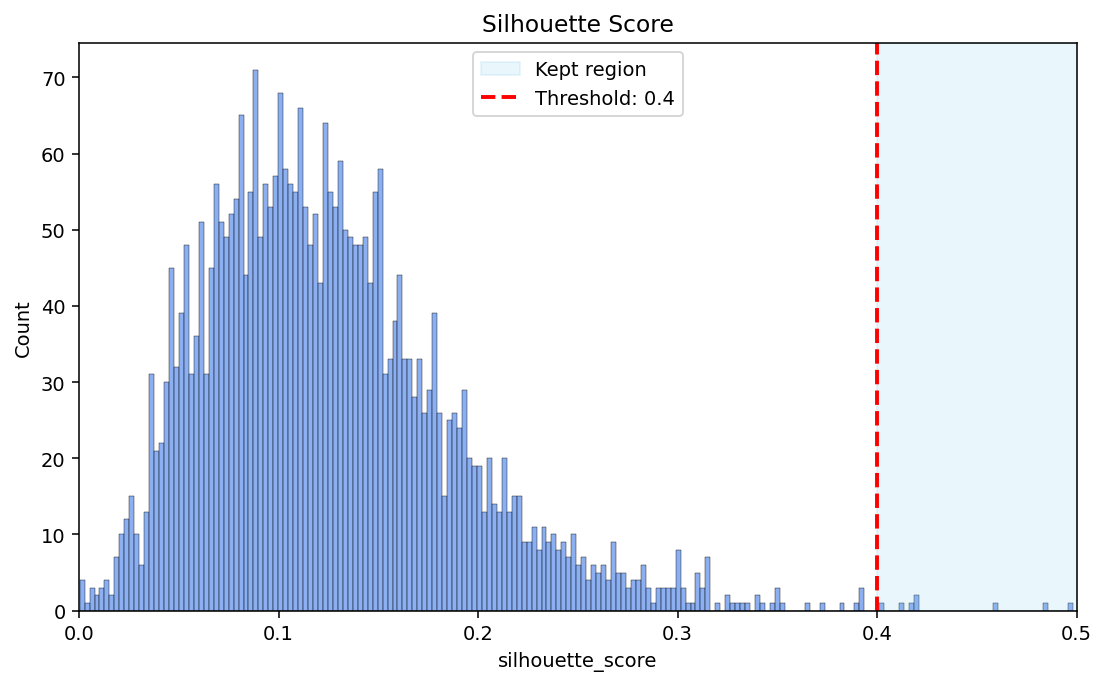

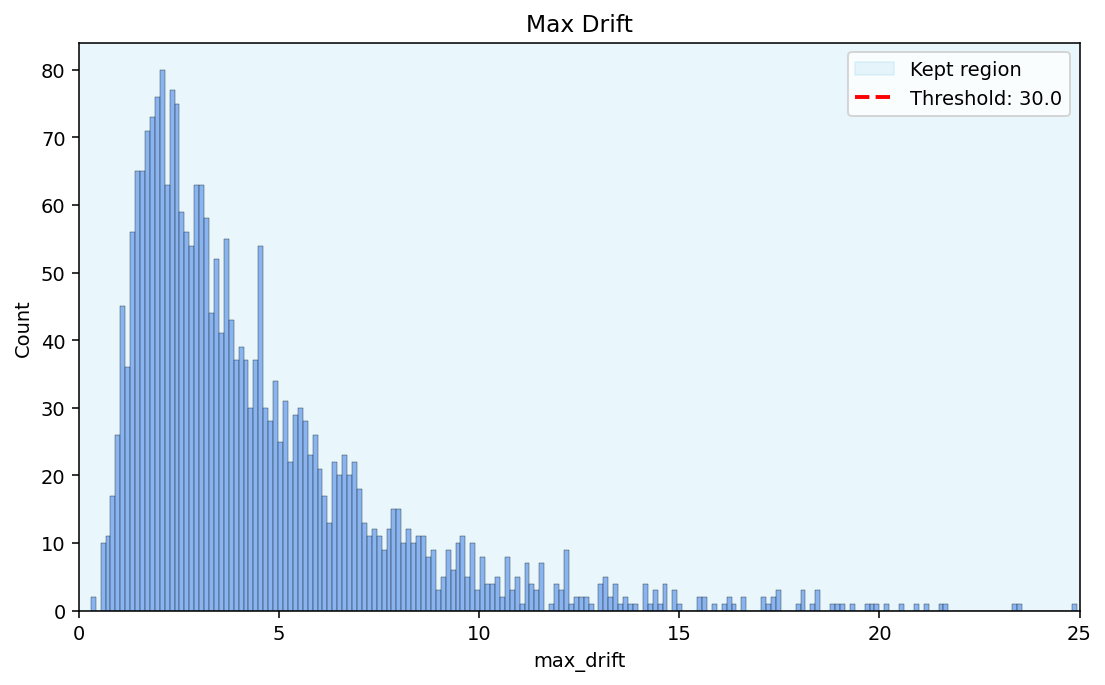

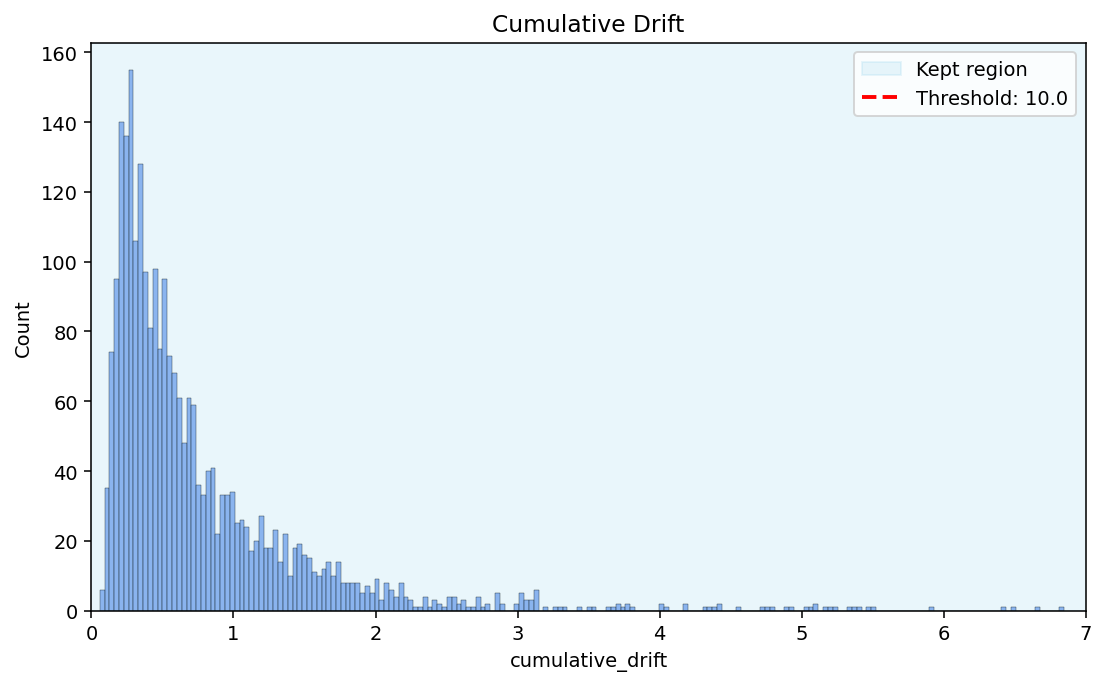

In [16]:
to_plot = "l_ratio"
hist_plot(df[to_plot], "L Ratio", bins=200, filename=f"hist_{to_plot}.png", xlim=(0, 2.5), qc_threshold=qc_thresholds_secondary[to_plot])

to_plot = "d_prime"
hist_plot(df[to_plot], "D Prime", bins=200, filename=f"hist_{to_plot}.png", qc_threshold=qc_thresholds_secondary[to_plot])

to_plot = "nn_hit_rate"
hist_plot(df[to_plot], "Nearest Neighbor Hit Rate", bins=200, filename=f"hist_{to_plot}.png", qc_threshold=qc_thresholds_secondary[to_plot])

to_plot = "nn_miss_rate"
hist_plot(df[to_plot], "Nearest Neighbor Miss Rate", bins=200, filename=f"hist_{to_plot}.png", xlim=(0, 0.3), qc_threshold=qc_thresholds_secondary[to_plot])

to_plot = "silhouette_score"
hist_plot(df[to_plot], "Silhouette Score", bins=200, filename=f"hist_{to_plot}.png", xlim=(0, 0.5), qc_threshold=qc_thresholds_secondary[to_plot])

to_plot = "max_drift"
hist_plot(df[to_plot], "Max Drift", bins=200, filename=f"hist_{to_plot}.png", xlim=(0, 25), qc_threshold=qc_thresholds_secondary[to_plot])

to_plot = "cumulative_drift"
hist_plot(df[to_plot], "Cumulative Drift", bins=200, filename=f"hist_{to_plot}.png", xlim=(0, 7), qc_threshold=qc_thresholds_secondary[to_plot])

In [17]:
def apply_rule(series: pd.Series, op: str, val: float) -> pd.Series:
    if op == "<":
        return series < val
    elif op == "<=":
        return series <= val
    elif op == ">":
        return series > val
    elif op == ">=":
        return series >= val
    elif op == "==":
        return series == val
    else:
        return pd.Series(False, index=series.index)

In [18]:
qc_mask_parts = []
for metric, (op, val) in qc_thresholds.items():
    if metric in df.columns:
        m = apply_rule(df[metric], op, val)
        qc_mask_parts.append(m.fillna(False))
        df[f"qc_pass_{metric}"] = m
    else:
        df[f"qc_pass_{metric}"] = False

if qc_mask_parts:
    df["qc_pass_all"] = np.logical_and.reduce(qc_mask_parts)
else:
    df["qc_pass_all"] = False

# ---- 3) Summary tables ----
summary_overall = pd.DataFrame({
    "total_units": [len(df)],
    "qc_pass_units": [int(df["qc_pass_all"].sum())],
    "qc_pass_pct": [float(100.0 * df["qc_pass_all"].mean()) if len(df) else 0.0],
})

# Per-session (if session_id present), else per-datetime
group_key = "session_id" if df["session_id"].notna().any() else "datetime"
summary_by_session = (
    df.groupby(group_key, dropna=False)
      .agg(total_units=("unit_id", "count"),
           qc_pass_units=("qc_pass_all", "sum"))
      .reset_index()
)
summary_by_session["qc_pass_pct"] = 100.0 * summary_by_session["qc_pass_units"] / summary_by_session["total_units"]

# Per-region
summary_by_region = (
    df.groupby("region", dropna=False)
      .agg(total_units=("unit_id", "count"),
           qc_pass_units=("qc_pass_all", "sum"))
      .reset_index()
)
summary_by_region["qc_pass_pct"] = 100.0 * summary_by_region["qc_pass_units"] / summary_by_region["total_units"]

# Save summaries
summary_overall_path = qc_dir / "qc_summary_overall.csv"
summary_session_path = qc_dir / "qc_summary_by_session.csv"
summary_region_path = qc_dir / "qc_summary_by_region.csv"

summary_overall.to_csv(summary_overall_path, index=False)
summary_by_session.to_csv(summary_session_path, index=False)
summary_by_region.to_csv(summary_region_path, index=False)

# Display tables in the UI
display(summary_overall)
display(summary_by_session.sort_values("qc_pass_pct", ascending=False))
display(summary_by_region.sort_values("qc_pass_pct", ascending=False))

,total_units,qc_pass_units,qc_pass_pct
0,3620,2254,62.265193


,session_id,total_units,qc_pass_units,qc_pass_pct
27,RZ050_2024-11-21_v1,2,2,100.000000
41,RZ055_2024-10-30_str,6,6,100.000000
29,RZ050_2024-11-22_v1,3,3,100.000000
33,RZ051_2024-11-21_str,13,12,92.307692
13,RZ039_2024-07-17_str,16,14,87.500000
...,...,...,...,...
10,RZ038_2024-07-17_v1,2,0,0.000000
34,RZ051_2024-11-21_v1,3,0,0.000000
56,RZ058_2025-03-13_v1,9,0,0.000000
37,RZ052_2024-10-25_v1,4,0,0.000000


,region,total_units,qc_pass_units,qc_pass_pct
0,str,2731,1746,63.932625
1,v1,889,508,57.142857


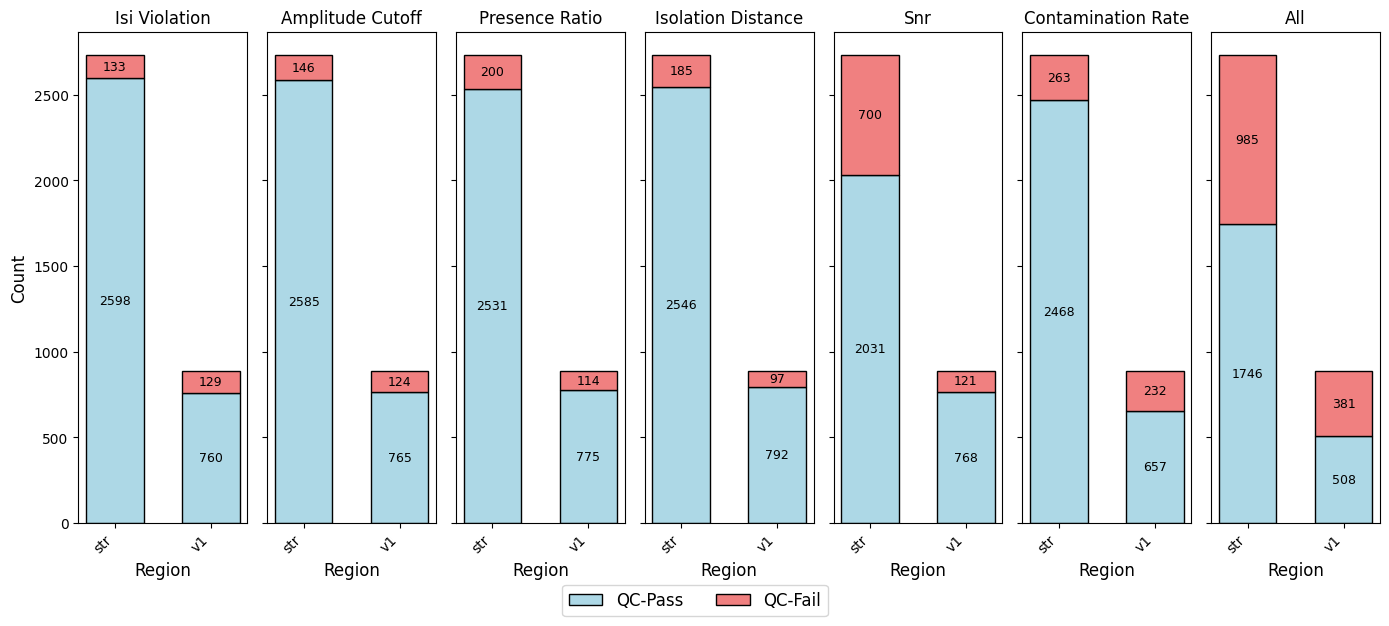

In [19]:
qc_metrics = [
    'qc_pass_isi_violation',
    'qc_pass_amplitude_cutoff',
    'qc_pass_presence_ratio',
    'qc_pass_isolation_distance',
    'qc_pass_snr',
    'qc_pass_contamination_rate',
    'qc_pass_all'
]

fig, axs = plt.subplots(1, len(qc_metrics), figsize=(2 * len(qc_metrics), 6), sharey=True)

for i, metric in enumerate(qc_metrics):
    region_qc_counts = df.groupby(['region', metric]).size().reset_index(name='count')
    pivot_qc = region_qc_counts.pivot(index='region', columns=metric, values='count').fillna(0)
    pivot_qc = pivot_qc.reindex(columns=[True, False], fill_value=0)
    x = np.arange(len(pivot_qc.index))
    bars_pass = axs[i].bar(x, pivot_qc[True], width=0.6, label='QC-Pass', color='lightblue', edgecolor='black')
    bars_fail = axs[i].bar(x, pivot_qc[False], width=0.6, bottom=pivot_qc[True], label='QC-Fail', color='lightcoral', edgecolor='black')
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(pivot_qc.index, rotation=45, ha='right', fontsize=10)
    axs[i].set_title(metric.replace('qc_pass_', '').replace('_', ' ').title())
    axs[i].set_xlabel('Region', fontsize=12)
    # Add value labels
    for bar in bars_pass + bars_fail:
        height = bar.get_height()
        if height > 0:
            axs[i].text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{int(height)}',
                        ha='center', va='center', fontsize=9, color='black')
    if i == 0:
        axs[i].set_ylabel('Count', fontsize=12)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(qc_dir, 'region_qc_metrics_counts.png'), dpi=300, bbox_inches='tight')

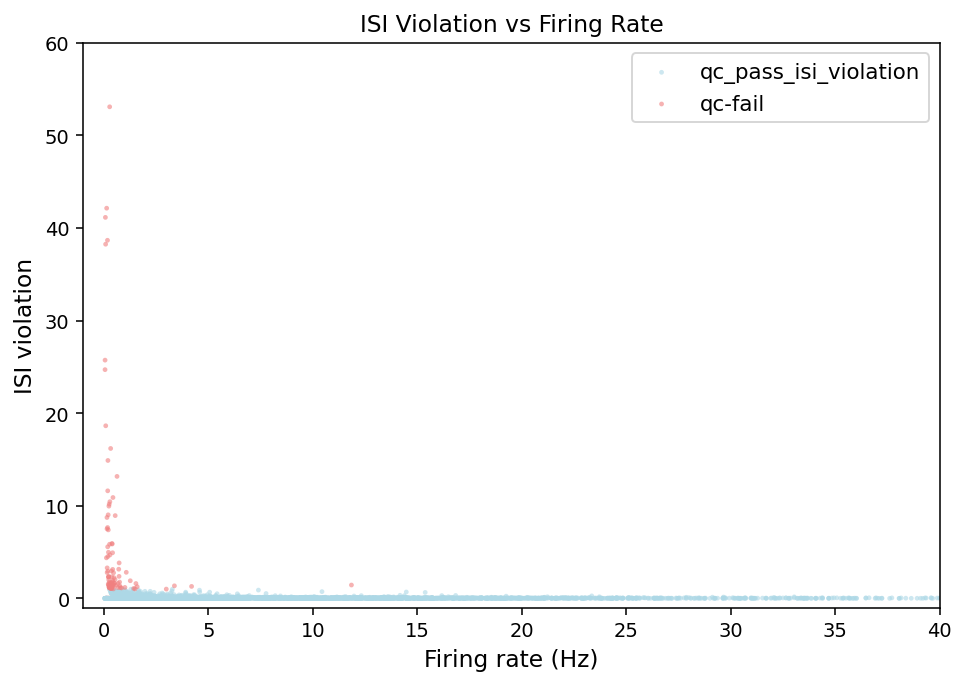

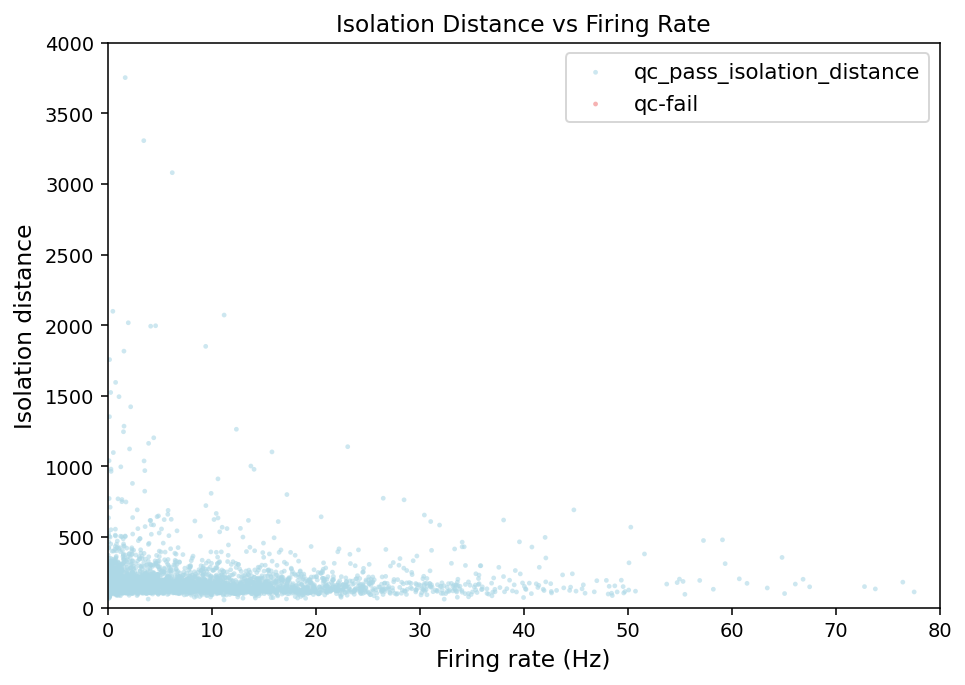

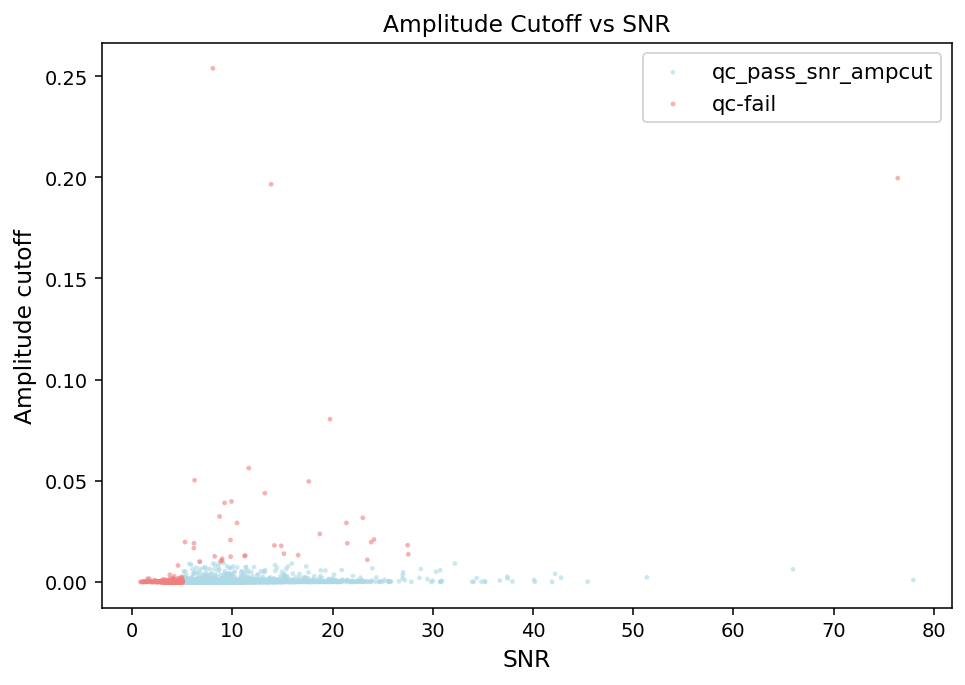

In [20]:
def scatter_plot(df, x_col, y_col, qc_pass_col, title, xlabel, ylabel, alpha=0.6, filename=None, xlim=None, ylim=None):
    x = df[x_col]
    y = df[y_col]
    qc_pass = df[qc_pass_col]
    mask = ~(np.isnan(x.values) | np.isnan(y.values) | pd.isnull(qc_pass.values))
    xclean = x.values[mask]
    yclean = y.values[mask]
    qc_clean = qc_pass.values[mask]

    plt.figure(figsize=(7, 5), dpi=140)
    for val, color, label in zip([True, False], ['lightblue', 'lightcoral'], [qc_pass_col, 'qc-fail']):
        idx = qc_clean == val
        plt.scatter(xclean[idx], yclean[idx], alpha=alpha, s=6, color=color, label=label, edgecolor='none')
    plt.title(title)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(fontsize=11)
    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.tight_layout()
    if filename:
        plt.savefig(qc_dir / filename, bbox_inches="tight")
    plt.show()

# Usage examples:
scatter_plot(df, "firing_rate", "isi_violation", "qc_pass_isi_violation",
             "ISI Violation vs Firing Rate", "Firing rate (Hz)", "ISI violation",
             filename="scat_fr_vs_isi.png",
             xlim=(-1, 40), ylim=(-1, 60))

scatter_plot(df, "firing_rate", "isolation_distance", "qc_pass_isolation_distance",
             "Isolation Distance vs Firing Rate", "Firing rate (Hz)", "Isolation distance",
             filename="scat_fr_vs_iso.png",
             xlim=(0, 80), ylim=(0, 4000))

df["qc_pass_snr_ampcut"] = df["qc_pass_snr"] & df["qc_pass_amplitude_cutoff"]
scatter_plot(df, "snr", "amplitude_cutoff", "qc_pass_snr_ampcut",
             "Amplitude Cutoff vs SNR", "SNR", "Amplitude cutoff",
             filename="scat_snr_vs_ampcut.png")

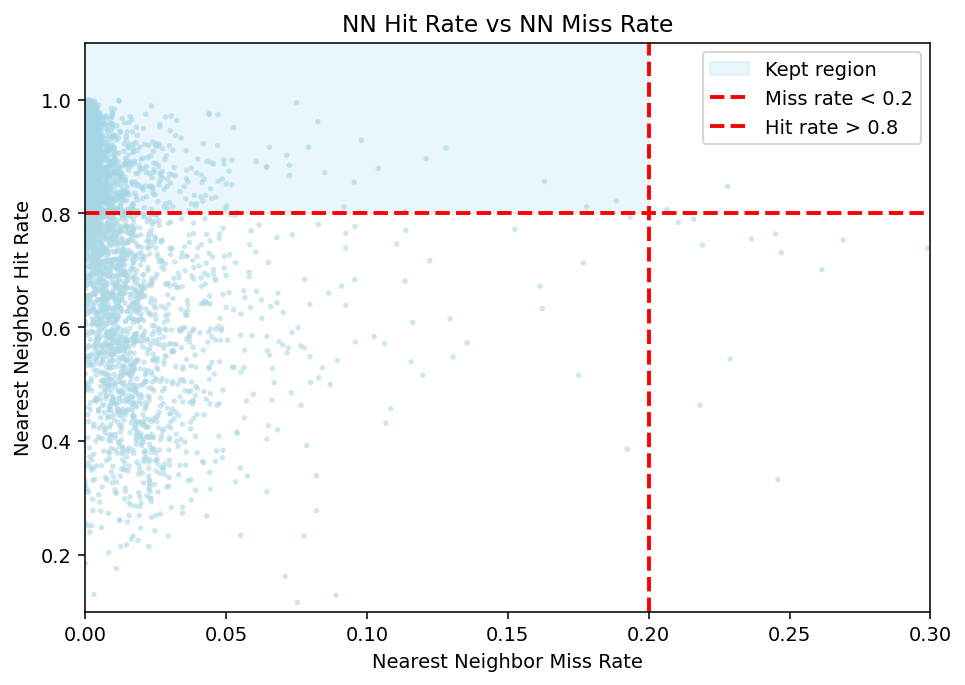

In [21]:
plt.figure(figsize=(7, 5), dpi=140)
plt.scatter(df['nn_miss_rate'], df['nn_hit_rate'], alpha=0.6, s=8, color='lightblue', edgecolor='none')

miss_thresh = qc_thresholds_secondary["nn_miss_rate"][1]  # < 0.2
hit_thresh = qc_thresholds_secondary["nn_hit_rate"][1]    # > 0.8

xlim = plt.xlim(0, 0.3)
ylim = plt.ylim(0.1, 1.1)
x = np.linspace(xlim[0], miss_thresh, 100)
plt.fill_between(x, hit_thresh, ylim[1], color='skyblue', alpha=0.18, label='Kept region')

plt.axvline(miss_thresh, color='red', linestyle='--', linewidth=2, label=f'Miss rate < {miss_thresh}')
plt.axhline(hit_thresh, color='red', linestyle='--', linewidth=2, label=f'Hit rate > {hit_thresh}')
plt.xlabel("Nearest Neighbor Miss Rate")
plt.ylabel("Nearest Neighbor Hit Rate")
plt.title("NN Hit Rate vs NN Miss Rate")
plt.legend()
plt.tight_layout()
plt.savefig(qc_dir / "scat_nn_hit_vs_miss.png", bbox_inches="tight")
# plt.show()

In [22]:
df = df.merge(
        sessions_all[['session_id', 'length']],
        on='session_id',
        how='left'
    )

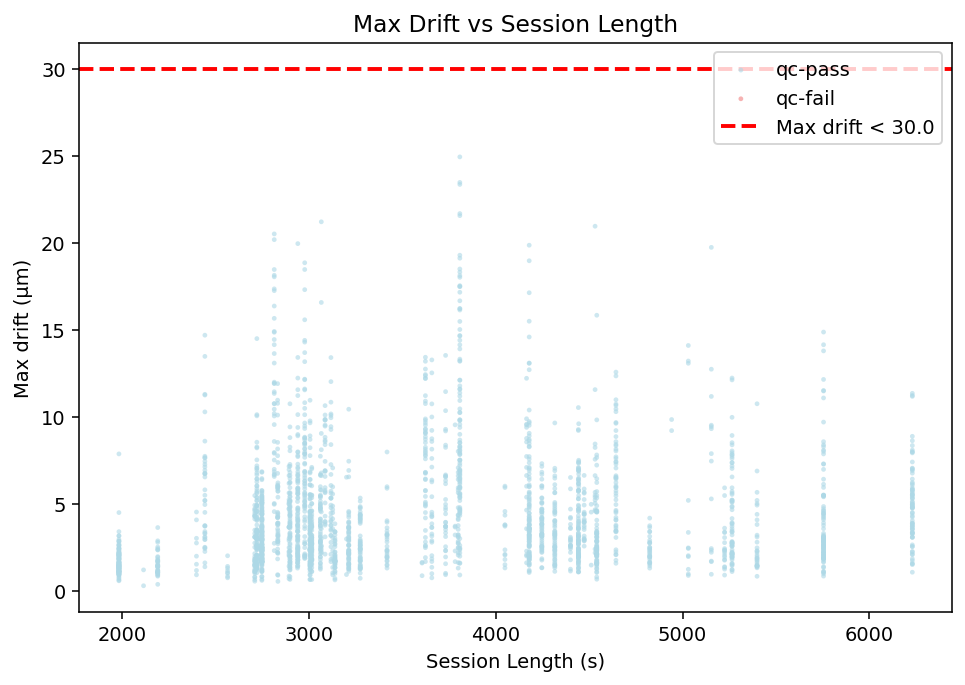

In [23]:
x = df["length"]
y = df["max_drift"]

# Define QC mask
df['qc_pass_max_drift'] = (
    (df['firing_rate'] > qc_thresholds["firing_rate"][1]) &
    (df['max_drift'] < qc_thresholds_secondary["max_drift"][1])
)
qc_pass_max_drift = df['qc_pass_max_drift']

mask = ~(np.isnan(x.values) | np.isnan(y.values))
xclean = x.values[mask]
yclean = y.values[mask]
qc_clean = qc_pass_max_drift.values[mask]

plt.figure(figsize=(7, 5), dpi=140)
plt.scatter(xclean[qc_clean], yclean[qc_clean], alpha=0.6, s=6, color='lightblue', label='qc-pass', edgecolor='none')
plt.scatter(xclean[~qc_clean], yclean[~qc_clean], alpha=0.6, s=6, color='lightcoral', label='qc-fail', edgecolor='none')

fr_thresh = qc_thresholds["firing_rate"][1]
drift_thresh = qc_thresholds_secondary["max_drift"][1]
plt.axhline(drift_thresh, color='red', linestyle='--', linewidth=2, label=f'Max drift < {drift_thresh}')

plt.title("Max Drift vs Session Length")
plt.xlabel("Session Length (s)")
plt.ylabel("Max drift (µm)")
plt.legend()
plt.tight_layout()
plt.savefig(qc_dir / "scat_session_length_vs_maxdrift.png", bbox_inches="tight")

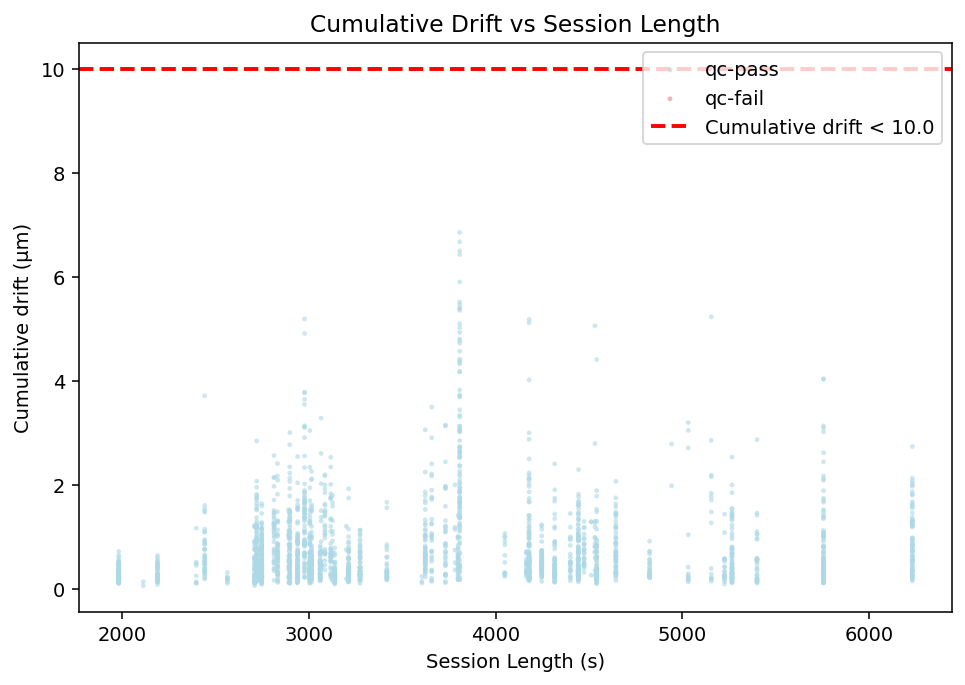

In [24]:
x = df["length"]
y = df["cumulative_drift"]

# Define QC mask
df['qc_pass_cumulative_drift'] = (
    (df['firing_rate'] > qc_thresholds["firing_rate"][1]) &
    (df['cumulative_drift'] < qc_thresholds_secondary["cumulative_drift"][1])
)
qc_pass_cumulative_drift = df['qc_pass_cumulative_drift']

mask = ~(np.isnan(x.values) | np.isnan(y.values))
xclean = x.values[mask]
yclean = y.values[mask]
qc_clean = qc_pass_cumulative_drift.values[mask]

plt.figure(figsize=(7, 5), dpi=140)
plt.scatter(xclean[qc_clean], yclean[qc_clean], alpha=0.6, s=6, color='lightblue', label='qc-pass', edgecolor='none')
plt.scatter(xclean[~qc_clean], yclean[~qc_clean], alpha=0.6, s=6, color='lightcoral', label='qc-fail', edgecolor='none')

fr_thresh = qc_thresholds["firing_rate"][1]
drift_thresh = qc_thresholds_secondary["cumulative_drift"][1]
plt.axhline(drift_thresh, color='red', linestyle='--', linewidth=2, label=f'Cumulative drift < {drift_thresh}')

plt.title("Cumulative Drift vs Session Length")
plt.xlabel("Session Length (s)")
plt.ylabel("Cumulative drift (µm)")
plt.legend()
plt.tight_layout()
plt.savefig(qc_dir / "scat_session_length_vs_cumudrift.png", bbox_inches="tight")

In [25]:
# ---- 7) Save a per-unit pass/fail export for your records/slides ----
pass_cols = ["qc_pass_all"] + [c for c in df.columns if c.startswith("qc_pass_")]
export_cols = [
    "session_id", "datetime", "mouse", "region", "insertion_number",
    "unit_id", "firing_rate", "snr", "presence_ratio", "isi_violation",
    "amplitude_cutoff", "isolation_distance", "contamination_rate", "max_drift",
    "manual_label"
] + pass_cols

units_qc = df[export_cols].copy()
per_unit_path = p.LOGS_DIR / "qc_per_unit_with_pass_flags.csv"
units_qc.to_csv(per_unit_path, index=False)